In [1]:
import os
import numpy as np
import pandas as pd

# 📂BitNet

In [2]:
testdf = pd.read_csv("/home/kannika/code/Testdf_15ABrf_newCase.csv")
print(testdf.shape)
testdf.head()

(1312, 28)


,Unnamed: 0,Unnamed: 0.1,Case,Abs Position,Sub Position,Class,Sub_class,Path Full,Path Crop,Views,...,Rtop,Rwidth,Rheight,filename,15AB_category,15AB_Prob,15AB_ProbAll,Predict_15AB,AI_Predic_CCA,Act_Predic_CCA
0,0,0,AB01_40,P1,P1,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,0.148873,0.513514,0.346614,AB01 P1 C040.JPG,Normal,0.413035,"[0.21054949660106018, 0.15272910155885105, 0.0...",Incorrect,Non_SuspectedCCA,Non_SuspectedCCA
1,1,1,AB01_40,P2,P2,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,0.154849,0.560377,0.428287,AB01 P2 C040.JPG,AB01,0.741650,"[0.741650235419515, 0.07765986354655634, 0.003...",Correct,Non_SuspectedCCA,Non_SuspectedCCA
2,2,2,AB01_40,P4,P41,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,...,0.150865,0.667984,0.711155,AB01 P4-1 C040.JPG,AB02,0.432403,"[0.34931351731971466, 0.43240273685662617, 0.0...",Incorrect,Non_SuspectedCCA,Non_SuspectedCCA
3,3,3,AB01_40,P5,P51,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,...,0.107041,0.690385,0.653386,AB01 P5-1 C040.JPG,AB01,0.345768,"[0.3457682703694028, 0.1947838428977293, 0.021...",Correct,Non_SuspectedCCA,Non_SuspectedCCA
4,4,4,AB01_40,P3,P31,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,...,0.146881,0.672515,0.625498,AB01 P3-1 C040.JPG,AB02,0.540886,"[0.15631073449826405, 0.5408859454791868, 0.02...",Incorrect,Non_SuspectedCCA,Non_SuspectedCCA


In [3]:
testdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1312 entries, 0 to 1311
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      1312 non-null   int64  
 1   Unnamed: 0.1    1312 non-null   int64  
 2   Case            1312 non-null   object 
 3   Abs Position    1312 non-null   object 
 4   Sub Position    1312 non-null   object 
 5   Class           1312 non-null   object 
 6   Sub_class       1312 non-null   object 
 7   Path Full       1312 non-null   object 
 8   Path Crop       1312 non-null   object 
 9   Views           1312 non-null   object 
 10  fold            1312 non-null   int64  
 11  tagName         1312 non-null   object 
 12  originalImage   455 non-null    object 
 13  left            455 non-null    float64
 14  top             455 non-null    float64
 15  width           455 non-null    float64
 16  height          455 non-null    float64
 17  Rleft           455 non-null    f

In [4]:
data_train = testdf
#เช็คคลาสใน Predicted
pred_class = set(data_train['15AB_category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB07', 'AB06', 'AB09', 'AB12', 'AB03', 'AB081', 'AB04', 'Normal', 'AB05', 'AB083', 'AB11', 'AB10', 'AB02', 'AB082', 'AB01'}
Actual :  15
{'AB07', 'AB06', 'AB09', 'AB12', 'AB03', 'AB081', 'AB04', 'AB05', 'AB083', 'AB11', 'AB10', 'Normal', 'AB02', 'AB082', 'AB01'}


In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class'].array
pred = data_train['15AB_category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 86.8140243902439%
              precision    recall  f1-score   support

        AB01       0.79      0.61      0.69        74
        AB02       0.59      0.60      0.60        60
        AB03       0.50      0.50      0.50        18
        AB04       0.88      0.65      0.75        43
        AB05       0.83      0.66      0.73        29
        AB06       0.83      0.48      0.61        21
        AB07       0.71      0.48      0.57        21
       AB081       0.78      0.56      0.65        32
       AB082       0.79      0.54      0.64        28
       AB083       0.80      0.36      0.50        11
        AB09       1.00      0.77      0.87        26
        AB10       0.80      0.40      0.53        10
        AB11       0.86      0.83      0.84        23
        AB12       0.88      0.85      0.86        59
      Normal       0.90      0.99      0.95       857

    accuracy                           0.87      1312
   macro avg       0.80      0.62      0

Text(0.5, 21.5, 'Predicted label')

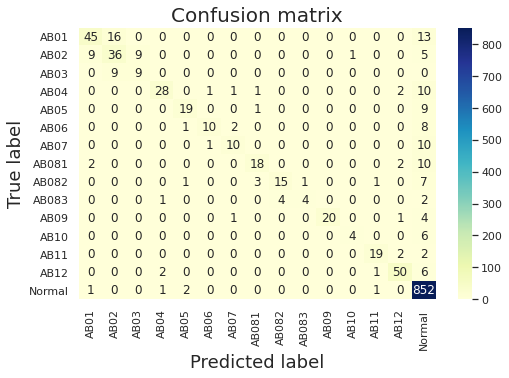

In [6]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

## ⚙️ Exclude Normal Class

'''
cmap = 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r'

'''

In [8]:
dataframe0_ = testdf[(testdf["Sub_class"]!="Normal") & (testdf['15AB_category']!="Normal")].reset_index(drop=True)
print(dataframe0_.shape)
dataframe0_.head()

(363, 28)


,Unnamed: 0,Unnamed: 0.1,Case,Abs Position,Sub Position,Class,Sub_class,Path Full,Path Crop,Views,...,Rtop,Rwidth,Rheight,filename,15AB_category,15AB_Prob,15AB_ProbAll,Predict_15AB,AI_Predic_CCA,Act_Predic_CCA
0,1,1,AB01_40,P2,P2,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,0.154849,0.560377,0.428287,AB01 P2 C040.JPG,AB01,0.741650,"[0.741650235419515, 0.07765986354655634, 0.003...",Correct,Non_SuspectedCCA,Non_SuspectedCCA
1,2,2,AB01_40,P4,P41,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,...,0.150865,0.667984,0.711155,AB01 P4-1 C040.JPG,AB02,0.432403,"[0.34931351731971466, 0.43240273685662617, 0.0...",Incorrect,Non_SuspectedCCA,Non_SuspectedCCA
2,3,3,AB01_40,P5,P51,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,...,0.107041,0.690385,0.653386,AB01 P5-1 C040.JPG,AB01,0.345768,"[0.3457682703694028, 0.1947838428977293, 0.021...",Correct,Non_SuspectedCCA,Non_SuspectedCCA
3,4,4,AB01_40,P3,P31,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,...,0.146881,0.672515,0.625498,AB01 P3-1 C040.JPG,AB02,0.540886,"[0.15631073449826405, 0.5408859454791868, 0.02...",Incorrect,Non_SuspectedCCA,Non_SuspectedCCA
4,5,5,AB02_40,P1,P1,Abnormal,AB02,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,0.129419,0.564007,0.464646,AB02 P1 C040.JPG,AB02,0.277998,"[0.11621040516872033, 0.2779976298345559, 0.06...",Correct,Non_SuspectedCCA,Non_SuspectedCCA


In [9]:
data_train = dataframe0_
#เช็คคลาสใน Predicted
pred_class = set(data_train['15AB_category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class'])
print('Actual : ',len(classe))
print(classe)

Predicted :  14
{'AB07', 'AB06', 'AB09', 'AB12', 'AB03', 'AB081', 'AB04', 'AB05', 'AB083', 'AB11', 'AB10', 'AB02', 'AB082', 'AB01'}
Actual :  14
{'AB07', 'AB06', 'AB09', 'AB12', 'AB03', 'AB081', 'AB04', 'AB05', 'AB083', 'AB11', 'AB10', 'AB02', 'AB082', 'AB01'}


In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = data_train['Sub_class'].array
pred = data_train['15AB_category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 79.0633608815427%
              precision    recall  f1-score   support

        AB01       0.80      0.74      0.77        61
        AB02       0.59      0.65      0.62        55
        AB03       0.50      0.50      0.50        18
        AB04       0.90      0.85      0.88        33
        AB05       0.90      0.95      0.93        20
        AB06       0.83      0.77      0.80        13
        AB07       0.71      0.91      0.80        11
       AB081       0.78      0.82      0.80        22
       AB082       0.79      0.71      0.75        21
       AB083       0.80      0.44      0.57         9
        AB09       1.00      0.91      0.95        22
        AB10       0.80      1.00      0.89         4
        AB11       0.90      0.90      0.90        21
        AB12       0.88      0.94      0.91        53

    accuracy                           0.79       363
   macro avg       0.80      0.79      0.79       363
weighted avg       0.80      0.79      0

Text(0.5, 21.5, 'Predicted label')

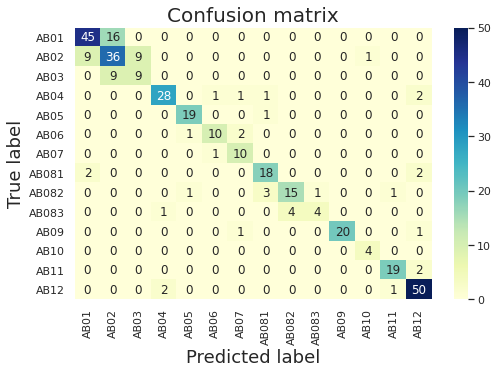

In [13]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

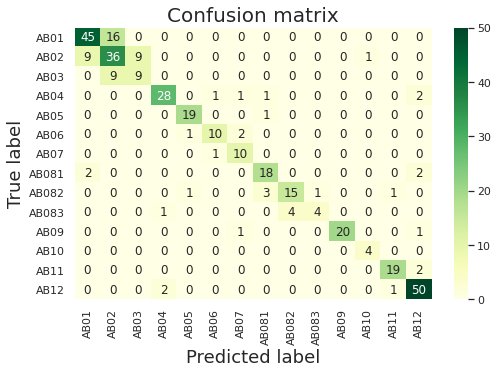

In [25]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
# Custom colormap for heatmap
#custom_cmap = sns.light_palette("YlGnBu", as_cmap=True, reverse=False)

sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGn") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)
plt.show()

# 📂EffNet

In [26]:
dataframe = pd.read_csv("/home/kannika/code/Testdf_res.csv")
print(dataframe.shape)
dataframe.head()

(1312, 35)


,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,Case,Abs Position,Sub Position,Class,Sub_class,Path Full,Path Crop,...,Predict_AN,Predict_15AB,FP_category,FP_Prob,FP_ProbAll,Predict_5FP,PathG,category_5FPNet,Prob_5FPNet,Predict_5FPNet
0,0,0,0,40,P1,P1,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,...,Incorrect,Incorrect,FP-B,0.475344,"[0.22316645916382064, 0.47534361094783256, 0.1...",Incorrect,/SSD/DATA/USAI/ABnormal01/1 ABNORMAL/cropped/A...,FP-A,0.999998,Correct
1,1,1,1,40,P2,P2,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,...,Correct,Correct,FP-B,0.421248,"[0.37420833333333337, 0.42124777662277657, 0.1...",Incorrect,/SSD/DATA/USAI/ABnormal01/1 ABNORMAL/cropped/A...,FP-A,1.000000,Correct
2,2,2,2,40,P4,P41,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,...,Correct,Incorrect,FP-B,0.539706,"[0.26481242746053524, 0.5397056655678111, 0.16...",Correct,/SSD/DATA/USAI/ABnormal01/1 ABNORMAL/cropped/A...,FP-B,1.000000,Correct
3,3,3,3,40,P5,P51,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,...,Correct,Correct,FP-C,0.369984,"[0.23283089826839828, 0.36367942889185334, 0.3...",Correct,/SSD/DATA/USAI/ABnormal01/1 ABNORMAL/cropped/A...,FP-C,1.000000,Correct
4,4,4,4,40,P3,P31,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,...,Correct,Incorrect,FP-B,0.470639,"[0.3576083715596331, 0.47063899180584956, 0.14...",Correct,/SSD/DATA/USAI/ABnormal01/1 ABNORMAL/cropped/A...,FP-B,0.988930,Correct


In [27]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1312 entries, 0 to 1311
Data columns (total 35 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       1312 non-null   int64  
 1   Unnamed: 0.1     1312 non-null   int64  
 2   Unnamed: 0.1.1   1312 non-null   int64  
 3   Case             1312 non-null   int64  
 4   Abs Position     1312 non-null   object 
 5   Sub Position     1312 non-null   object 
 6   Class            1312 non-null   object 
 7   Sub_class        1312 non-null   object 
 8   Path Full        1312 non-null   object 
 9   Path Crop        1312 non-null   object 
 10  Views            1312 non-null   object 
 11  fold             1312 non-null   int64  
 12  tagName          1312 non-null   object 
 13  originalImage    455 non-null    object 
 14  left             455 non-null    float64
 15  top              455 non-null    float64
 16  width            455 non-null    float64
 17  height        

In [28]:
dataframe[["Sub_class", "category"]]

,Sub_class,category
0,AB01,Normal
1,AB01,AB01
2,AB01,AB02
3,AB01,AB01
4,AB01,AB02
...,...,...
1307,Normal,Normal
1308,Normal,Normal
1309,Normal,Normal
1310,Normal,Normal


In [29]:
data_train = dataframe
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB07', 'AB06', 'AB09', 'AB12', 'AB03', 'AB081', 'AB04', 'Normal', 'AB05', 'AB083', 'AB11', 'AB10', 'AB02', 'AB082', 'AB01'}
Actual :  15
{'AB07', 'AB06', 'AB09', 'AB12', 'AB03', 'AB081', 'AB04', 'AB05', 'AB083', 'AB11', 'AB10', 'Normal', 'AB02', 'AB082', 'AB01'}


In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 85.89939024390245%
              precision    recall  f1-score   support

        AB01       0.78      0.54      0.64        74
        AB02       0.58      0.58      0.58        60
        AB03       0.43      0.50      0.46        18
        AB04       0.90      0.60      0.72        43
        AB05       0.86      0.66      0.75        29
        AB06       0.81      0.62      0.70        21
        AB07       0.91      0.48      0.62        21
       AB081       0.86      0.56      0.68        32
       AB082       0.79      0.54      0.64        28
       AB083       0.62      0.45      0.53        11
        AB09       1.00      0.73      0.84        26
        AB10       0.80      0.40      0.53        10
        AB11       1.00      0.43      0.61        23
        AB12       0.72      0.88      0.79        59
      Normal       0.90      0.99      0.94       857

    accuracy                           0.86      1312
   macro avg       0.80      0.60      

Text(0.5, 21.5, 'Predicted label')

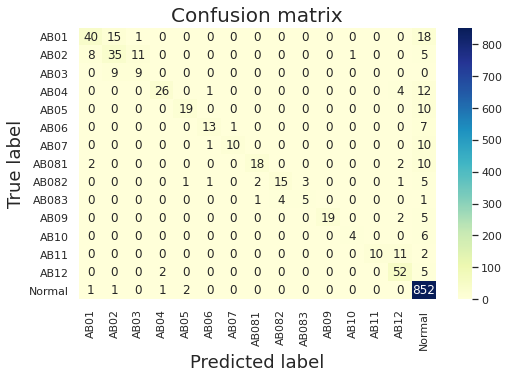

In [31]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

## ⚙️ Exclude Normal Class

In [32]:
dataframe0_ = dataframe[(dataframe["Sub_class"]!="Normal") & (dataframe['category']!="Normal")].reset_index(drop=True)
print(dataframe0_.shape)
dataframe0_.head()

(359, 35)


,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,Case,Abs Position,Sub Position,Class,Sub_class,Path Full,Path Crop,...,Predict_AN,Predict_15AB,FP_category,FP_Prob,FP_ProbAll,Predict_5FP,PathG,category_5FPNet,Prob_5FPNet,Predict_5FPNet
0,1,1,1,40,P2,P2,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,...,Correct,Correct,FP-B,0.421248,"[0.37420833333333337, 0.42124777662277657, 0.1...",Incorrect,/SSD/DATA/USAI/ABnormal01/1 ABNORMAL/cropped/A...,FP-A,1.000000,Correct
1,2,2,2,40,P4,P41,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,...,Correct,Incorrect,FP-B,0.539706,"[0.26481242746053524, 0.5397056655678111, 0.16...",Correct,/SSD/DATA/USAI/ABnormal01/1 ABNORMAL/cropped/A...,FP-B,1.000000,Correct
2,3,3,3,40,P5,P51,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,...,Correct,Correct,FP-C,0.369984,"[0.23283089826839828, 0.36367942889185334, 0.3...",Correct,/SSD/DATA/USAI/ABnormal01/1 ABNORMAL/cropped/A...,FP-C,1.000000,Correct
3,4,4,4,40,P3,P31,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,...,Correct,Incorrect,FP-B,0.470639,"[0.3576083715596331, 0.47063899180584956, 0.14...",Correct,/SSD/DATA/USAI/ABnormal01/1 ABNORMAL/cropped/A...,FP-B,0.988930,Correct
4,5,5,5,40,P1,P1,Abnormal,AB02,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,...,Correct,Correct,FP-B,0.395067,"[0.26781421460583354, 0.3950670115915257, 0.27...",Incorrect,/SSD/DATA/USAI/ABnormal01/2 ABNORMAL/cropped/A...,FP-A,0.999969,Correct


In [33]:
data_train = dataframe0_
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class'])
print('Actual : ',len(classe))
print(classe)

Predicted :  14
{'AB07', 'AB06', 'AB09', 'AB12', 'AB03', 'AB081', 'AB04', 'AB05', 'AB083', 'AB11', 'AB10', 'AB02', 'AB082', 'AB01'}
Actual :  14
{'AB07', 'AB06', 'AB09', 'AB12', 'AB03', 'AB081', 'AB04', 'AB05', 'AB083', 'AB11', 'AB10', 'AB02', 'AB082', 'AB01'}


In [34]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = data_train['Sub_class'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 76.6016713091922%
              precision    recall  f1-score   support

        AB01       0.80      0.71      0.75        56
        AB02       0.59      0.64      0.61        55
        AB03       0.43      0.50      0.46        18
        AB04       0.93      0.84      0.88        31
        AB05       0.95      1.00      0.97        19
        AB06       0.81      0.93      0.87        14
        AB07       0.91      0.91      0.91        11
       AB081       0.86      0.82      0.84        22
       AB082       0.79      0.65      0.71        23
       AB083       0.62      0.50      0.56        10
        AB09       1.00      0.90      0.95        21
        AB10       0.80      1.00      0.89         4
        AB11       1.00      0.48      0.65        21
        AB12       0.72      0.96      0.83        54

    accuracy                           0.77       359
   macro avg       0.80      0.77      0.78       359
weighted avg       0.78      0.77      0

Text(0.5, 21.5, 'Predicted label')

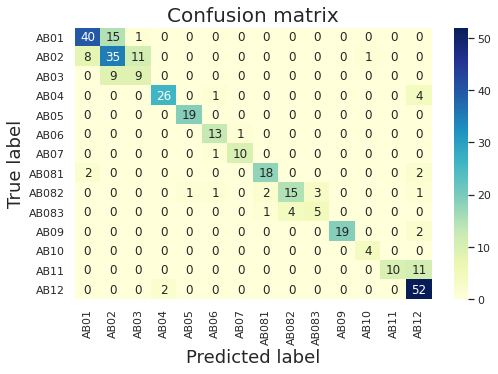

In [35]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

----

# BiTNet Model

In [31]:
testdf = pd.read_csv("/home/kannika/code/result_BiTNet.csv")
print(testdf.shape)
testdf.head()

(1312, 2055)


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,2044,2045,2046,2047,Class,SubPosition,Views,Sub_class,category,Prob
0,0,-0.107834,0.312153,0.017337,-0.183516,0.575318,-0.173991,-0.089335,-0.063324,-0.030139,...,0.148072,0.400463,0.140204,0.374979,Abnormal,P1,FP-A,AB01,Normal,0.413035
1,1,0.410596,0.660920,-0.136565,-0.185140,0.411923,-0.167171,0.004935,0.000345,-0.130163,...,-0.012626,0.236496,0.633177,0.092444,Abnormal,P2,FP-A,AB01,AB01,0.110668
2,2,-0.017506,0.345108,0.225856,-0.165460,0.779619,-0.193235,-0.032824,-0.147713,-0.096544,...,-0.005355,0.241840,0.390013,-0.130200,Abnormal,P41,FP-B,AB01,AB02,0.091490
3,3,-0.020903,0.117675,-0.082832,-0.135977,0.282651,-0.220009,0.111934,-0.094878,-0.103359,...,0.022169,0.057336,0.233832,-0.014271,Abnormal,P51,FP-C,AB01,AB01,0.075286
4,4,0.064263,0.339076,0.294470,-0.157962,0.194468,-0.202357,-0.088951,-0.190239,-0.139355,...,-0.076772,0.139161,0.083017,-0.109640,Abnormal,P31,FP-B,AB01,AB02,0.065060


In [32]:
data_train = testdf
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB082', 'AB11', 'AB10', 'AB01', 'AB02', 'AB06', 'AB12', 'AB081', 'AB083', 'Normal', 'AB05', 'AB04', 'AB07', 'AB09', 'AB03'}
Actual :  15
{'AB082', 'AB10', 'AB11', 'AB03', 'AB01', 'AB02', 'AB06', 'AB12', 'AB081', 'AB07', 'AB05', 'AB04', 'AB09', 'Normal', 'AB083'}


In [33]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 86.8140243902439%
              precision    recall  f1-score   support

        AB01       0.79      0.61      0.69        74
        AB02       0.59      0.60      0.60        60
        AB03       0.50      0.50      0.50        18
        AB04       0.88      0.65      0.75        43
        AB05       0.83      0.66      0.73        29
        AB06       0.83      0.48      0.61        21
        AB07       0.71      0.48      0.57        21
       AB081       0.78      0.56      0.65        32
       AB082       0.79      0.54      0.64        28
       AB083       0.80      0.36      0.50        11
        AB09       1.00      0.77      0.87        26
        AB10       0.80      0.40      0.53        10
        AB11       0.86      0.83      0.84        23
        AB12       0.88      0.85      0.86        59
      Normal       0.90      0.99      0.95       857

    accuracy                           0.87      1312
   macro avg       0.80      0.62      0

Text(0.5, 21.5, 'Predicted label')

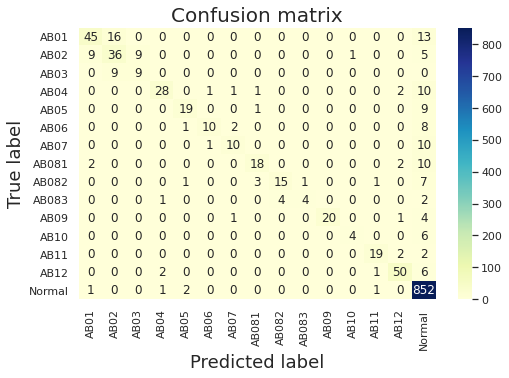

In [34]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [27]:
testdf = pd.read_csv("/home/kannika/code/PredictCase1312Cca_2Class.csv")
print(testdf.shape)
testdf.head()

(1312, 30)


,Unnamed: 0,Unnamed: 0.1,Case,Abs Position,Sub Position,Class,Sub_class,Path Full,Path Crop,Views,...,Rheight,filename,15AB_category,15AB_Prob,15AB_ProbAll,Predict_15AB,AI_Predic_CCA,Act_Predic_CCA,AiCase_Cca2Class,ActCase_Cca2class
0,0,0,40,P1,P1,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,0.346614,AB01 P1 C040.JPG,Normal,0.413035,"[0.21054949660106018, 0.15272910155885105, 0.0...",Incorrect,Non_SuspectedCCA,Non_SuspectedCCA,SuspectedCCA,SuspectedCCA
1,1,1,40,P2,P2,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,...,0.428287,AB01 P2 C040.JPG,AB01,0.741650,"[0.741650235419515, 0.07765986354655634, 0.003...",Correct,Non_SuspectedCCA,Non_SuspectedCCA,SuspectedCCA,SuspectedCCA
2,2,2,40,P4,P41,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,...,0.711155,AB01 P4-1 C040.JPG,AB02,0.432403,"[0.34931351731971466, 0.43240273685662617, 0.0...",Incorrect,Non_SuspectedCCA,Non_SuspectedCCA,SuspectedCCA,SuspectedCCA
3,3,3,40,P5,P51,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,...,0.653386,AB01 P5-1 C040.JPG,AB01,0.345768,"[0.3457682703694028, 0.1947838428977293, 0.021...",Correct,Non_SuspectedCCA,Non_SuspectedCCA,SuspectedCCA,SuspectedCCA
4,4,4,40,P3,P31,Abnormal,AB01,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,...,0.625498,AB01 P3-1 C040.JPG,AB02,0.540886,"[0.15631073449826405, 0.5408859454791868, 0.02...",Incorrect,Non_SuspectedCCA,Non_SuspectedCCA,SuspectedCCA,SuspectedCCA


In [28]:
data_train = testdf
#เช็คคลาสใน Predicted
pred_class = set(data_train['15AB_category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB082', 'AB11', 'AB10', 'AB01', 'AB02', 'AB06', 'AB12', 'AB081', 'AB083', 'Normal', 'AB05', 'AB04', 'AB07', 'AB09', 'AB03'}
Actual :  15
{'AB082', 'AB10', 'AB11', 'AB03', 'AB01', 'AB02', 'AB06', 'AB12', 'AB081', 'AB07', 'AB05', 'AB04', 'AB09', 'Normal', 'AB083'}


In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class'].array
pred = data_train['15AB_category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 86.8140243902439%
              precision    recall  f1-score   support

        AB01       0.79      0.61      0.69        74
        AB02       0.59      0.60      0.60        60
        AB03       0.50      0.50      0.50        18
        AB04       0.88      0.65      0.75        43
        AB05       0.83      0.66      0.73        29
        AB06       0.83      0.48      0.61        21
        AB07       0.71      0.48      0.57        21
       AB081       0.78      0.56      0.65        32
       AB082       0.79      0.54      0.64        28
       AB083       0.80      0.36      0.50        11
        AB09       1.00      0.77      0.87        26
        AB10       0.80      0.40      0.53        10
        AB11       0.86      0.83      0.84        23
        AB12       0.88      0.85      0.86        59
      Normal       0.90      0.99      0.95       857

    accuracy                           0.87      1312
   macro avg       0.80      0.62      0

----------------